# Brownfield Soil-Lead Risk Mapping with Probability Kriging (PROC KRIGE2D)

## Executive Summary

A municipal environmental health department uses **PROC KRIGE2D** to interpolate soil-lead concentrations across a 500 m x 500 m brownfield redevelopment parcel from 70 sparse borings, then converts the kriging prediction and its standard error into a **probability-of-exceedance map** for the EPA residential screening level (400 ppm). Of the 70 borings, only 8 (11.4%) measured above 400 ppm, but the kriged risk surface flags **7 of 64 grid nodes (10.9%) as High risk** (probability of exceedance at least 0.80) — all clustered along the east edge of the parcel, the footprint of a former smelter. Two grid nodes there reach a near-certain exceedance probability of 1.00 with kriged concentrations of 585 and 650 ppm. The result turns scattered point measurements into a defensible, uncertainty-aware remediation boundary.

## Data Sources

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `soil_samples` | 70 | `east`, `north` (m), `lead_ppm`, `log_pb` | Synthetic soil-boring lead measurements across the parcel. Concentrations follow a quadratic spatial trend (a contamination hot spot near the east edge, the former smelter footprint) plus a correlated Gaussian residual, modeled on the log scale to keep values positive and right-skewed. `log_pb = log(lead_ppm)` is the variable kriged. |
| `kriged` (OUTEST=) | 64 | `x`, `y`, `estimate`, `stderr` | KRIGE2D output: the ordinary-kriging prediction of `log_pb` (`estimate`) and its kriging standard error (`stderr`) at each node of an 8 x 8 (70 m spacing) grid spanning the parcel. |
| `risk` | 64 | `x`, `y`, `est_ppm`, `prob_exceed`, `risk_band` | Per-node risk product. Under the kriging-error normal model, `prob_exceed = P(log_pb > log 400) = 1 - CDF('normal', (log 400 - estimate)/stderr)`; `est_ppm = exp(estimate)`; `risk_band` buckets the probability into Low / Watch / Elevated / High. |

# Brownfield Soil-Lead Risk Mapping with PROC KRIGE2D

A city environmental health department has acquired a former industrial parcel (500 m x 500 m) slated for residential redevelopment. Seventy soil borings measured lead concentration, but the regulator needs a decision over the **entire** parcel: *where, and with what confidence, does soil lead exceed the EPA residential screening level of 400 ppm?*

A contour of the kriged "best estimate" alone answers *where* but not *with what confidence*. **PROC KRIGE2D** returns more than a point prediction at each location — it also returns a **kriging standard error** that grows with distance from the borings. Treating the prediction error as Gaussian, we convert each node's estimate and standard error into the **probability that the true concentration exceeds 400 ppm**. Mapping that probability — rather than a single contour line — gives the agency a risk-based product it can defend at a hearing: every node carries an explicit exceedance probability and an uncertainty band.

This notebook is fully self-contained: it synthesizes the survey data inline, krigs the lead field, and post-processes the kriging output into the risk map.

## Step 1 — Synthesize the soil-boring survey

We place 70 borings randomly across the parcel. Lead concentration is modeled on the **log scale** (so it stays positive and right-skewed, as real contamination data are):

- a **quadratic spatial trend** that peaks near the east edge — the footprint of a former smelter — and decays westward, and
- a spatially **correlated Gaussian residual** (a blend of two noise scales) so that nearby borings carry similar values.

The variable kriged downstream is `log_pb = log(lead_ppm)`.

In [1]:
data soil_samples;
   call streaminit(20250531);
   label lead_ppm = 'Soil Lead (ppm)'
         log_pb   = 'log Soil Lead';
   do i = 1 to 70;
      east  = 500 * rand('uniform');
      north = 500 * rand('uniform');

      /* Quadratic trend: hot spot near the east edge (east high, north low) */
      ex = east / 500;
      ny = north / 500;
      trend = 5.0 + 1.8*ex - 1.2*ny - 0.9*(ex-1)**2 - 0.7*ny**2;

      /* Spatially smooth correlated residual: blend two scales of shocks */
      resid = 0.55*rand('normal', 0, 1) + 0.45*rand('normal', 0, 0.6);

      log_pb   = trend + 0.35*resid;
      lead_ppm = exp(log_pb);
      output;
   end;
   drop i ex ny trend resid;
run;

NOTE: DATA soil_samples


NOTE: Wrote soil_samples (70 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the conditioning data

Before kriging we sanity-check the sample: the spatial extent of the borings, the distribution of measured lead, and how many borings already exceed the 400 ppm screening level.

                              Soil-Boring Survey: Coordinate Extent and Lead Distribution                               

                                                  The MEANS Procedure

 Variable               N     Minimum        Mean      Median   90th Pctl     Maximum
 ------------------------------------------------------------------------------------
 EAST                  70        16.1       254.0       248.1       435.5       491.4
 NORTH                 70         4.8       247.3       255.3       441.4       490.3
 Soil Lead (ppm)       70        20.6       179.1       122.8       436.2       760.6
 log Soil Lead         70         3.0         4.8         4.8         6.1         6.6
 ------------------------------------------------------------------------------------

                                 Fraction of Borings Above the 400 ppm Screening Level                                  

                                                   The FREQ Procedure

Boring Exce

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA flagged


NOTE: Read 70 rows from soil_samples.
NOTE: Wrote flagged (70 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_over_threshold.spec.json
NOTE: PROC FREQ statement used.


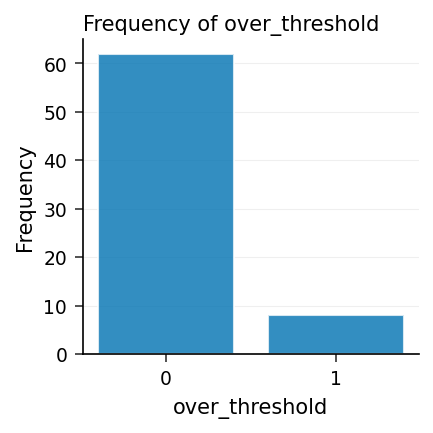

In [2]:
proc means data=soil_samples n min mean median p90 max maxdec=1;
   var east north lead_ppm log_pb;
   title 'Soil-Boring Survey: Coordinate Extent and Lead Distribution';
run;

data flagged;
   set soil_samples;
   over_threshold = (lead_ppm > 400);
run;

proc freq data=flagged;
   tables over_threshold / nocum;
   label over_threshold = 'Boring Exceeds 400 ppm';
   title 'Fraction of Borings Above the 400 ppm Screening Level';
run;

## Step 3 — Krige the lead field with PROC KRIGE2D

We interpolate `log_pb` onto an 8 x 8 grid (70 m spacing, 64 nodes) spanning the parcel. Key choices:

- `coordinates xc=east yc=north` ties the kriging system to the boring locations.
- `predict var=log_pb r=300` predicts the log-lead surface using borings within a 300 m search radius of each grid node.
- `model form=gaussian scale=0.13 range=150 nugget=0.01` specifies the semivariogram: a Gaussian covariance with a practical range of ~150 m, a partial sill (`scale`) of 0.13 matching the residual variance on the log scale, and a small nugget for fine-scale noise.
- `grid x= … y= …` defines the prediction lattice.

The `OUTEST=kriged` dataset captures, for every node, the kriging `estimate` of `log_pb` and its `stderr` — the two ingredients of the risk map.

                                 Fraction of Borings Above the 400 ppm Screening Level                                  

   The KRIGE2D Procedure   
     Model Information     

Item                  Value
-----------------  --------
Variogram Model    GAUSSIAN
Kriging Method     ORDINARY
Observations Used        70
Prediction Points        64



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote kriged (64 rows, 4 columns).
NOTE: ODS Graphics is OFF.


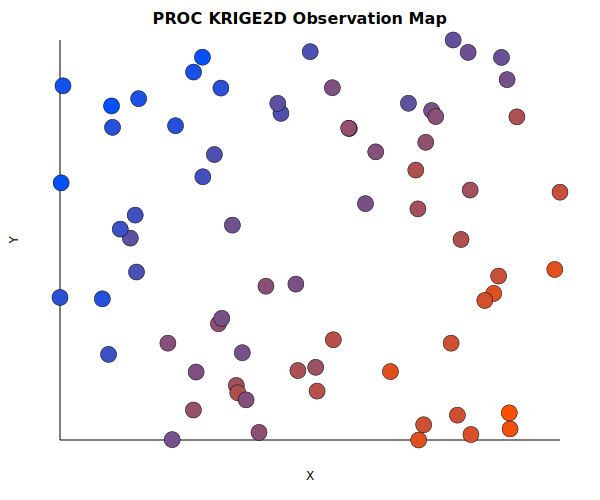

In [3]:
ods graphics on;

proc krige2d data=soil_samples outest=kriged
             plots=(observations prediction);
   coordinates xc=east yc=north;
   predict var=log_pb r=300;
   grid x=0 to 500 by 70
        y=0 to 500 by 70;
   model scale=0.13 range=150 form=gaussian nugget=0.01;
   title 'Ordinary Kriging of log Soil Lead';
run;

ods graphics off;

## Step 4 — Build the probability-of-exceedance map

The `OUTEST=` dataset holds, at every grid node, the kriging prediction of `log_pb` (`estimate`) and its standard error (`stderr`). Treating the prediction error as Gaussian, the probability that the true log-lead exceeds the log of the 400 ppm threshold is

`P(log_pb > log 400) = 1 - CDF('normal', (log 400 - estimate) / stderr)`.

We compute that probability at every node, back-transform the estimate to ppm (`est_ppm = exp(estimate)`), and bucket the probability into four risk bands. The grouped scatter renders the map: each grid node is colored by its risk band, so the high-risk cluster along the east edge is immediately visible.

                                 Fraction of Borings Above the 400 ppm Screening Level                                  



NOTE: DATA risk


NOTE: Read 64 rows from kriged.
NOTE: Wrote risk (64 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=risk

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


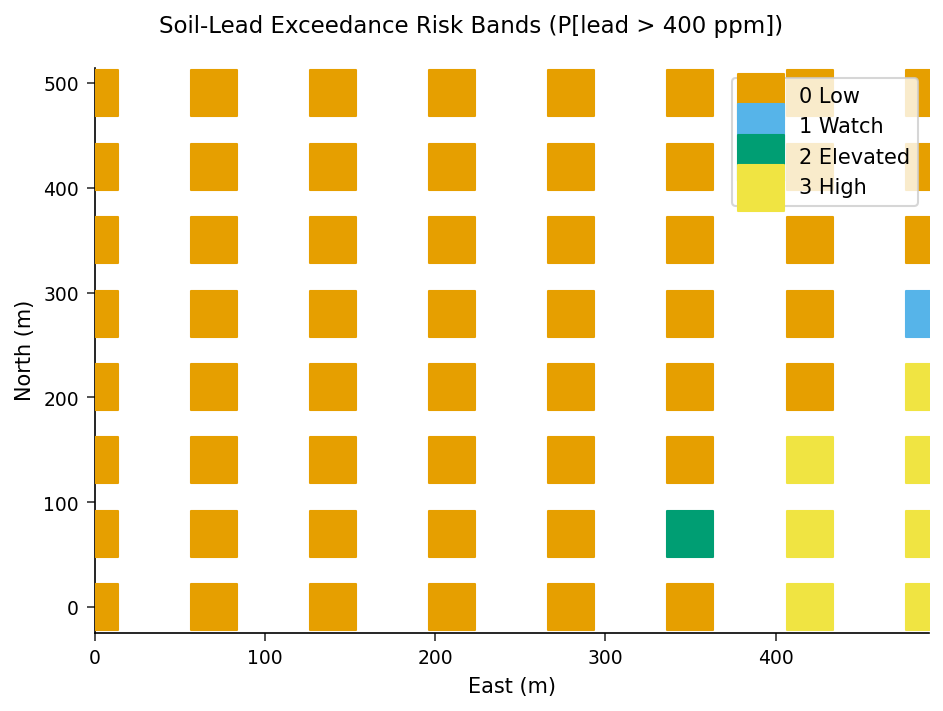

In [4]:
data risk;
   set kriged;
   thresh      = log(400);
   est_ppm     = exp(estimate);
   z           = (thresh - estimate) / stderr;
   prob_exceed = 1 - cdf('normal', z);
   length risk_band $12;
   if      prob_exceed >= 0.80 then risk_band = '3 High';
   else if prob_exceed >= 0.50 then risk_band = '2 Elevated';
   else if prob_exceed >= 0.20 then risk_band = '1 Watch';
   else                              risk_band = '0 Low';
   label est_ppm     = 'Kriged Lead (ppm)'
         prob_exceed = 'P(lead > 400 ppm)';
run;

ods graphics on;

proc sgplot data=risk;
   scatter x=x y=y / group=risk_band
           markerattrs=(symbol=squarefilled size=22);
   xaxis label='East (m)';
   yaxis label='North (m)';
   title 'Soil-Lead Exceedance Risk Bands (P[lead > 400 ppm])';
run;

ods graphics off;

## Step 5 — Summarize parcel-wide risk

Three views support the remediation decision:

1. **How much of the grid is at risk?** A summary of the kriged estimate and exceedance probability across all 64 nodes.
2. **Where is action almost certain?** The grid nodes whose exceedance probability is at least 0.50 — candidate excavation zones — with their kriged concentration.
3. **How are nodes distributed across risk bands?** A frequency of Low / Watch / Elevated / High.

In [5]:
proc means data=risk n mean min max maxdec=3;
   var est_ppm prob_exceed;
   title 'Kriged Lead Estimate and Exceedance Probability Across the 64-Node Grid';
run;

proc print data=risk noobs label;
   where prob_exceed >= 0.50;
   var x y est_ppm prob_exceed;
   label x='East (m)' y='North (m)';
   format est_ppm 6.0 prob_exceed 5.2;
   title 'High-Confidence Exceedance Zones (P >= 0.50)';
run;

proc freq data=risk;
   tables risk_band / nocum;
   label risk_band='Exceedance Risk Band';
   title 'Grid Nodes by Exceedance Risk Band';
run;

                        Kriged Lead Estimate and Exceedance Probability Across the 64-Node Grid                         

                                                  The MEANS Procedure

 Variable                 N           Mean     Minimum     Maximum
 -----------------------------------------------------------------
 Kriged Lead (ppm)       64        174.493      24.582     649.891
 P(lead > 400 ppm)       64          0.124       0.000       0.999
 -----------------------------------------------------------------

                                      High-Confidence Exceedance Zones (P >= 0.50)                                      

East (m)  North (m)  Kriged Lead (ppm)  P(lead > 400 ppm)
     420          0                481               0.93
     490          0                518               0.92
     350         70                425               0.70
     420         70                585               1.00
     490         70                650               1.00
 

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=risk

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Step 6 — How much does kriging uncertainty vary across the parcel?

The exceedance probabilities are only as trustworthy as the kriging standard error that drives them. `PROC UNIVARIATE` characterizes how `stderr` (on the log scale) is distributed across the 64 grid nodes — small near the borings, larger in the gaps between them. This tells the agency where the risk map itself is least certain and where an additional confirmation boring would most reduce uncertainty.

In [6]:
proc univariate data=kriged;
   var stderr;
   label stderr='Kriging Standard Error (log ppm)';
   ods select Quantiles ExtremeObs;
   title 'Spread of Kriging Standard Error Across the Grid';
run;

                                    Spread of Kriging Standard Error Across the Grid                                    

                                                The UNIVARIATE Procedure
                                 Variable:  STDERR  (Kriging Standard Error (log ppm))

                                                        Moments

N                                 64    Sum Weights                       64
Mean                        0.135924    Sum Observations            8.699157
Std Deviation               0.032745    Variance                    0.001072
Skewness                    2.484836    Kurtosis                    7.972790
Uncorrected SS              1.249980    Corrected SS                0.067553
Coeff Variation            24.090967    Std Error Mean              0.004093

        Basic Statistical Measures         

Location            Variability            
--------  --------  -------------  --------
Mean      0.135924  Std Deviation  0.032745
Median    0.

NOTE: PROC UNIVARIATE


## Interpreting the results

Probability kriging converts 70 sparse borings into a parcel-wide, uncertainty-aware risk picture:

- **The exceedance map** (Steps 4–5) replaces a single kriged contour with a *probability* at every grid node. The kriged lead estimate ranges from 25 to 650 ppm across the 64 nodes (mean 174 ppm), and the exceedance probability spans the full 0.00–1.00 range (mean 0.12). The risk-band frequency shows **7 nodes (10.9%) in the High band** (P ≥ 0.80) and **1 each in Elevated and Watch**, with the remaining 55 (85.9%) Low.
- **The High-confidence zone list** delineates a defensible excavation boundary rather than an arbitrary contour: all eight nodes with P ≥ 0.50 sit at east 350–490 m, the former smelter edge. Two of them — (420, 70) and (490, 70) — reach an exceedance probability of 1.00 at kriged concentrations of 585 and 650 ppm, the clear priority for excavation.
- **The kriging-error spread** (Step 6) shows the standard error has a median of about 0.12 log-ppm but a long upper tail (95th percentile near 0.20, maximum 0.29). The nodes where the error is largest are the gaps farthest from any boring — exactly where a confirmation boring would most sharpen the risk map.

Because the kriging system honors the observed borings, the agency can show regulators and residents that the risk map is consistent with the field data while still quantifying the irreducible uncertainty between sample points. Note the contrast with the raw survey: only 11.4% of *borings* exceeded 400 ppm, yet the kriged surface concentrates that risk into a compact, high-probability zone along the east edge — a sharper target than the scattered exceedances alone would suggest. Natural next steps are to fit the semivariogram empirically with `PROC VARIOGRAM` (rather than asserting `scale`/`range`/`nugget`), and to run a full conditional simulation with `PROC SIM2D` to capture joint uncertainty across nodes for volume estimation.